# 이탈 예측 모델 EDA 및 학습

이 노트북은 상관관계 시각화와 이탈 예측 모델 학습 과정을 함께 정리한 것입니다.

In [1]:
from pathlib import Path
import json

import joblib
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

# Windows/Jupyter 환경에서 한글 그래프가 깨지지 않도록 폰트를 우선 설정한다.
preferred_fonts = ['Malgun Gothic', 'AppleGothic', 'NanumGothic']
available_fonts = {f.name for f in fm.fontManager.ttflist}
for font_name in preferred_fonts:
    if font_name in available_fonts:
        plt.rcParams['font.family'] = font_name
        break
plt.rcParams['axes.unicode_minus'] = False


## 1) 데이터 불러오기 및 상관관계 산점도 (상위 2개 특성)

- 원본 데이터는 `insurance_policyholder_churn_synthetic.csv` 한 개를 사용합니다.
- 타깃 변수는 `churn_flag`이며, 고객 식별자나 정답 누설 가능성이 있는 컬럼은 학습에서 제외합니다.
- 먼저 수치형 변수 기준으로 타깃과의 상관관계를 확인하고, 상위 2개 특성을 산점도로 저장합니다.
- 이 단계는 어떤 변수가 이탈과 가장 직접적으로 연결되는지 빠르게 확인하기 위한 EDA 단계입니다.

In [2]:
def find_project_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / 'data' / 'insurance_policyholder_churn_synthetic.csv').exists():
            return candidate
    raise FileNotFoundError('프로젝트 루트를 찾지 못했습니다.')

project_root = find_project_root()
data_path = project_root / 'data' / 'insurance_policyholder_churn_synthetic.csv'
df = pd.read_csv(data_path)

target_col = 'churn_flag'
drop_cols = ['customer_id', 'as_of_date', 'churn_type', 'churn_probability_true']
drop_cols = [c for c in drop_cols if c in df.columns]

numeric_df = df.drop(columns=drop_cols).select_dtypes(include=['number'])
corr = numeric_df.corr(numeric_only=True)[target_col].drop(labels=[target_col])
top2 = corr.abs().sort_values(ascending=False).head(2).index.tolist()
x_col, y_col = top2

fig, ax = plt.subplots(figsize=(6.5, 5), dpi=140)
for label, color in [(0, '#4C78A8'), (1, '#F58518')]:
    subset = df[df[target_col] == label]
    ax.scatter(subset[x_col], subset[y_col], s=12, alpha=0.45, label=f'{target_col}={label}', color=color)

ax.set_title('Top Correlated Features vs Target')
ax.set_xlabel(x_col)
ax.set_ylabel(y_col)
ax.legend()
fig.tight_layout()

out_path = project_root / 'model' / 'target_corr_scatter.png'
out_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(out_path, bbox_inches='tight')
plt.close(fig)

print(f'Saved plot to: {out_path}')
print(f'Top correlated features: {x_col}, {y_col}')


Saved plot to: C:\lecture\PRED-CUST-CHURN\model\target_corr_scatter.png
Top correlated features: premium_change_pct, multi_policy_flag


## 2) 학습용 함수 정의

이 단계에서는 전처리, 파생변수 생성, 기준값 선택 함수를 정의합니다.

### 전처리
- 범주형 변수: 최빈값으로 결측치를 채운 뒤 원-핫 인코딩합니다.
- 수치형 변수: 중앙값으로 결측치를 채웁니다.
- 현재 모델은 트리 기반이므로 별도의 표준화나 정규화는 적용하지 않습니다.

### 파생변수 생성 이유
단일 변수만 보는 것보다, 실제 이탈 전조를 더 잘 드러내는 조합 신호를 만들기 위해 파생변수를 추가합니다.

- `premium_increase_shock`: 보험료 인상폭과 최근 인상 횟수를 함께 반영해 가격 충격 강도를 표현
- `premium_jump_flag`: 보험료가 크게 오른 이벤트 자체를 이진 신호로 표현
- `payment_risk_score`: 연체 횟수와 납부 누락 여부를 합쳐 납부 불안정 정도를 표현
- `service_risk_score`: 민원, 비교 견적 요청, 보장 축소를 묶어 이탈 전조 행동을 표현
- `engagement_risk_score`: 납부 위험과 서비스 위험을 합쳐 전체 이탈 위험 신호를 표현
- `tenure_inverse`: 가입 기간이 짧을수록 위험이 커지는 비선형 패턴을 강조
- `single_policy_short_tenure`: 단기 고객이면서 복수 계약이 아닌 경우 결속도가 약하다는 가설 반영
- `premium_x_complaint`: 보험료 급등과 민원이 동시에 있을 때의 상호작용 반영
- `premium_x_quote`: 보험료 급등 후 타사 비교 행동이 나온 경우 반영
- `late_x_quote`: 연체와 비교 견적 요청이 함께 나타나는 경우 반영
- `downgrade_x_quote`: 보장 축소와 비교 견적 요청이 함께 나타나는 경우 반영
- `monthly_payment_flag`: 월납 고객 여부를 별도 표시
- `monthly_x_premium_jump`: 월납 고객에게 보험료 급등이 더 크게 체감될 수 있다는 가설 반영
- `auto_or_health`: 가격 민감도가 상대적으로 클 수 있는 상품군을 단순 그룹화

### 조합 변수 효과를 확인하는 방법
- 상관계수: 단일 변수의 선형 관계를 빠르게 확인
- Permutation Importance: 모델 전체 기준으로 어떤 변수가 예측에 실제로 기여하는지 확인
- Partial Dependence Plot(PDP): 한두 개 변수 조합이 예측 확률을 어떻게 바꾸는지 평균적으로 확인
- ICE Plot: 개별 고객 수준에서 변수 변화가 예측에 어떤 영향을 주는지 확인
- SHAP / SHAP interaction value: 변수 기여도와 변수 간 상호작용을 가장 해석력 높게 확인하는 방법

현재 노트북은 우선 파생변수 생성과 성능 개선에 집중하고 있으며, 상호작용 해석은 이후 단계에서 추가 가능합니다.

In [3]:
def build_preprocessor(X: pd.DataFrame) -> ColumnTransformer:
    cat_cols = X.select_dtypes(include=['object', 'category', 'string']).columns.tolist()
    num_cols = [c for c in X.columns if c not in cat_cols]

    cat_pipe = Pipeline(
        steps=[
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
        ]
    )
    num_pipe = Pipeline(
        steps=[('imputer', SimpleImputer(strategy='median'))]
    )

    return ColumnTransformer(
        transformers=[
            ('cat', cat_pipe, cat_cols),
            ('num', num_pipe, num_cols),
        ],
        remainder='drop',
    )


def add_engineered_features(X: pd.DataFrame) -> pd.DataFrame:
    result = X.copy()
    result['premium_increase_shock'] = np.clip(result['premium_change_pct'], 0, None) * (1 + result['num_price_increases_last_3y'])
    result['premium_jump_flag'] = (result['premium_change_pct'] >= 0.12).astype(int)
    result['payment_risk_score'] = result['late_payment_count_12m'] + result['missed_payment_flag'] * 2
    result['service_risk_score'] = result['complaint_flag'] + result['quote_requested_flag'] + result['coverage_downgrade_flag']
    result['engagement_risk_score'] = result['payment_risk_score'] + result['service_risk_score']
    result['tenure_inverse'] = 1 / (result['customer_tenure_months'] + 1)
    result['single_policy_short_tenure'] = ((result['multi_policy_flag'] == 0) & (result['customer_tenure_months'] <= 24)).astype(int)
    result['premium_x_complaint'] = result['premium_jump_flag'] * result['complaint_flag']
    result['premium_x_quote'] = result['premium_jump_flag'] * result['quote_requested_flag']
    result['late_x_quote'] = (result['late_payment_count_12m'] >= 2).astype(int) * result['quote_requested_flag']
    result['downgrade_x_quote'] = result['coverage_downgrade_flag'] * result['quote_requested_flag']
    result['monthly_payment_flag'] = (result['payment_frequency'] == 'Monthly').astype(int)
    result['monthly_x_premium_jump'] = result['monthly_payment_flag'] * result['premium_jump_flag']
    result['auto_or_health'] = result['policy_type'].isin(['Auto', 'Health']).astype(int)
    return result


def fbeta_score_from_pr(precision: np.ndarray, recall: np.ndarray, beta: float) -> np.ndarray:
    beta2 = beta * beta
    return (1 + beta2) * (precision * recall) / (beta2 * precision + recall + 1e-12)


def select_threshold(thresholds, precision, recall, opt_metric='f1', min_precision=0.0, min_recall=0.0):
    if opt_metric == 'f2':
        scores = fbeta_score_from_pr(precision, recall, beta=2.0)
    else:
        scores = fbeta_score_from_pr(precision, recall, beta=1.0)

    mask = (precision >= min_precision) & (recall >= min_recall)
    if mask.any():
        idx = int(np.nanargmax(scores * mask))
        return float(thresholds[idx])

    idx = int(np.nanargmax(scores))
    return float(thresholds[idx])


def select_threshold_by_accuracy(y_true, y_prob, thresholds):
    candidate_thresholds = np.unique(np.clip(np.concatenate(([0.0], thresholds, [1.0])), 0.0, 1.0))
    best_threshold = 0.5
    best_accuracy = -1.0

    for threshold in candidate_thresholds:
        y_pred = (y_prob >= threshold).astype(int)
        accuracy = accuracy_score(y_true, y_pred)
        if accuracy > best_accuracy:
            best_accuracy = accuracy
            best_threshold = float(threshold)

    return best_threshold, best_accuracy


def save_threshold_plot(y_true, y_prob, selected_threshold, out_path):
    precision, recall, thresholds = precision_recall_curve(y_true, y_prob)
    thresholds = thresholds.astype(float)
    precision_t = precision[1:]
    recall_t = recall[1:]
    f1 = fbeta_score_from_pr(precision_t, recall_t, beta=1.0)
    f2 = fbeta_score_from_pr(precision_t, recall_t, beta=2.0)

    fig, axes = plt.subplots(1, 3, figsize=(16, 4), dpi=140)
    axes[0].plot(recall, precision, color='#4C78A8')
    axes[0].set_title('PR Curve')
    axes[0].set_xlabel('Recall')
    axes[0].set_ylabel('Precision')

    axes[1].plot(thresholds, recall_t, label='Recall', color='#1F77B4')
    axes[1].plot(thresholds, precision_t, label='Precision', color='#FF7F0E')
    axes[1].plot(thresholds, f1, label='F1', color='#2CA02C', linestyle='--')
    axes[1].plot(thresholds, f2, label='F2', color='#9467BD', linestyle='--')
    axes[1].axvline(selected_threshold, color='red', linestyle=':', label='Selected')
    axes[1].set_title('Threshold vs Metrics')
    axes[1].set_xlabel('Threshold')
    axes[1].set_ylabel('Score')
    axes[1].legend(fontsize=8)

    axes[2].scatter(thresholds, f2, s=12, color='#7F7F7F')
    axes[2].axvline(selected_threshold, color='red', linestyle=':')
    axes[2].set_title('F2 by Threshold')
    axes[2].set_xlabel('Threshold')
    axes[2].set_ylabel('F2')

    fig.tight_layout()
    out_path = Path(out_path)
    out_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(out_path, bbox_inches='tight')
    plt.close(fig)


## 3) 모델 학습

- 학습 전 `customer_id`, `as_of_date`, `churn_type`, `churn_probability_true`는 제외합니다.
- 남은 원본 변수에 위에서 정의한 파생변수를 추가해 최종 학습 입력을 만듭니다.
- 데이터는 `train 60% / validation 20% / test 20%` 구조로 나눕니다.
- 모델은 `HistGradientBoostingClassifier`를 사용합니다.
- validation 세트에서 `precision >= 0.3`, `recall >= 0.85` 조건 안에서 F2가 가장 좋은 기준값을 선택합니다.
- 마지막으로 train+validation 전체로 다시 학습한 모델을 test 세트에서 평가하고 저장합니다.

In [4]:
target_col = 'churn_flag'
drop_cols = ['customer_id', 'as_of_date', 'churn_type', 'churn_probability_true']
drop_cols = [c for c in drop_cols if c in df.columns]

y = df[target_col].astype(int).to_numpy()
X = df.drop(columns=drop_cols + [target_col])
X = add_engineered_features(X)

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.25, random_state=42, stratify=y_train_full
)

preprocessor = build_preprocessor(X_train)
model = HistGradientBoostingClassifier(
    learning_rate=0.05,
    max_depth=None,
    max_iter=400,
    l2_regularization=0.0,
    max_leaf_nodes=31,
    min_samples_leaf=20,
    random_state=42,
)

pipeline = Pipeline(
    steps=[('preprocess', preprocessor), ('model', model)]
)

pipeline.fit(X_train, y_train)

y_val_prob = pipeline.predict_proba(X_val)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_val, y_val_prob)
thresholds = thresholds.astype(float)
precision_t = precision[1:]
recall_t = recall[1:]

threshold = select_threshold(
    thresholds=thresholds,
    precision=precision_t,
    recall=recall_t,
    opt_metric='f2',
    min_precision=0.3,
    min_recall=0.85,
)

final_preprocessor = build_preprocessor(X_train_full)
final_pipeline = Pipeline(
    steps=[
        ('preprocess', final_preprocessor),
        ('model', HistGradientBoostingClassifier(
            learning_rate=0.05,
            max_depth=None,
            max_iter=400,
            l2_regularization=0.0,
            max_leaf_nodes=31,
            min_samples_leaf=20,
            random_state=42,
        )),
    ]
)
final_pipeline.fit(X_train_full, y_train_full)

y_prob = final_pipeline.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= threshold).astype(int)

auc = roc_auc_score(y_test, y_prob)
pr_auc = average_precision_score(y_test, y_prob)
val_acc = accuracy_score(y_val, (y_val_prob >= threshold).astype(int))
val_recall = ((y_val_prob >= threshold).astype(int)[y_val == 1]).mean()
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(f'ROC AUC: {auc:.4f}')
print(f'PR AUC: {pr_auc:.4f}')
print(f'Accuracy: {acc:.4f}')
print(f'F1: {f1:.4f}')
print(f'Validation Accuracy: {val_acc:.4f}')
print(f'Validation Recall: {val_recall:.4f}')
print(f'Selected threshold (F2 / Recall-focused): {threshold:.4f}')
print('Confusion Matrix:')
print(cm)
print('Classification Report:')
print(classification_report(y_test, y_pred, digits=4))

save_threshold_plot(
    y_true=y_test,
    y_prob=y_prob,
    selected_threshold=threshold,
    out_path=project_root / 'model' / 'threshold_analysis_new.png',
)
print(f"Saved threshold plot to: {project_root / 'model' / 'threshold_analysis_new.png'}")

joblib.dump(final_pipeline, project_root / 'model' / 'churn_model_new.pkl')
joblib.dump(threshold, project_root / 'model' / 'threshold_new.pkl')
print(f"Saved model to: {project_root / 'model' / 'churn_model_new.pkl'}")
print(f"Saved threshold to: {project_root / 'model' / 'threshold_new.pkl'}")


ROC AUC: 0.7898
PR AUC: 0.6626
Accuracy: 0.5720
F1: 0.5594
Validation Accuracy: 0.5721
Validation Recall: 0.9002
Selected threshold (F2 / Recall-focused): 0.1669
Confusion Matrix:
[[3003 3980]
 [ 300 2717]]
Classification Report:
              precision    recall  f1-score   support

           0     0.9092    0.4300    0.5839      6983
           1     0.4057    0.9006    0.5594      3017

    accuracy                         0.5720     10000
   macro avg     0.6574    0.6653    0.5716     10000
weighted avg     0.7573    0.5720    0.5765     10000

Saved threshold plot to: C:\lecture\PRED-CUST-CHURN\model\threshold_analysis_new.png
Saved model to: C:\lecture\PRED-CUST-CHURN\model\churn_model_new.pkl
Saved threshold to: C:\lecture\PRED-CUST-CHURN\model\threshold_new.pkl


## 4) 가설별 위험 신호 요약

모델 학습에 앞서 이탈 가설을 몇 가지 묶음으로 정리할 수 있습니다.

- 가격 충격 가설: 보험료 인상폭과 인상 횟수가 커질수록 이탈 가능성이 높아진다.
- 납부 불안정 가설: 연체와 납부 누락이 누적될수록 이탈 가능성이 높아진다.
- 서비스 불만 가설: 민원, 보장 축소, 비교 견적 요청이 나타나면 이탈 가능성이 높아진다.
- 계약 결속도 가설: 가입 기간이 짧고 복수 계약이 없을수록 이탈 가능성이 높아진다.

아래 표와 그래프는 위 가설들을 변수 묶음으로 만들어 실제 이탈률 차이를 빠르게 확인하기 위한 보조 분석입니다.

,가설 묶음,평균 위험 점수,최고 구간 이탈률
0,가격 충격,0.82,47.92
1,납부 불안정,0.11,89.78
2,서비스 불만,0.25,76.19
3,계약 결속도 약함,0.81,57.55


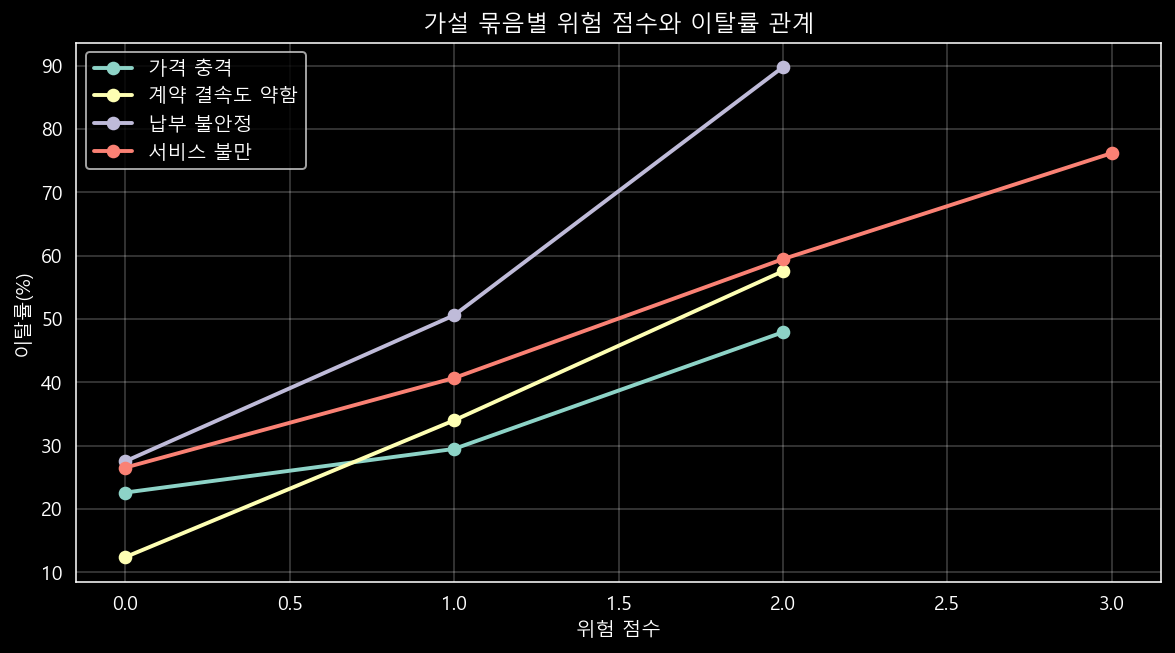

In [5]:
# 가설별 위험 신호 점수를 만들어 고객군별 이탈률을 요약한다.
if 'df' not in globals():
    from pathlib import Path
    import pandas as pd
    def find_project_root(start: Path | None = None) -> Path:
        current = (start or Path.cwd()).resolve()
        for candidate in [current, *current.parents]:
            if (candidate / 'data' / 'insurance_policyholder_churn_synthetic.csv').exists():
                return candidate
        raise FileNotFoundError('프로젝트 루트를 찾지 못했습니다.')
    project_root = find_project_root()
    df = pd.read_csv(project_root / 'data' / 'insurance_policyholder_churn_synthetic.csv')

hypothesis_df = df.copy()
hypothesis_df['price_risk_score'] = (
    (hypothesis_df['premium_change_pct'] >= 0.12).astype(int)
    + (hypothesis_df['num_price_increases_last_3y'] >= 2).astype(int)
)
hypothesis_df['payment_hyp_score'] = (
    (hypothesis_df['late_payment_count_12m'] >= 2).astype(int)
    + hypothesis_df['missed_payment_flag'].astype(int)
)
hypothesis_df['service_hyp_score'] = (
    hypothesis_df['complaint_flag'].astype(int)
    + hypothesis_df['quote_requested_flag'].astype(int)
    + hypothesis_df['coverage_downgrade_flag'].astype(int)
)
hypothesis_df['retention_hyp_score'] = (
    (hypothesis_df['customer_tenure_months'] <= 24).astype(int)
    + (hypothesis_df['multi_policy_flag'] == 0).astype(int)
)

hypothesis_summary = pd.DataFrame(
    [
        ('가격 충격', hypothesis_df['price_risk_score'].mean(), hypothesis_df.groupby('price_risk_score')['churn_flag'].mean().max()),
        ('납부 불안정', hypothesis_df['payment_hyp_score'].mean(), hypothesis_df.groupby('payment_hyp_score')['churn_flag'].mean().max()),
        ('서비스 불만', hypothesis_df['service_hyp_score'].mean(), hypothesis_df.groupby('service_hyp_score')['churn_flag'].mean().max()),
        ('계약 결속도 약함', hypothesis_df['retention_hyp_score'].mean(), hypothesis_df.groupby('retention_hyp_score')['churn_flag'].mean().max()),
    ],
    columns=['가설 묶음', '평균 위험 점수', '최고 구간 이탈률']
)
hypothesis_summary['평균 위험 점수'] = hypothesis_summary['평균 위험 점수'].round(2)
hypothesis_summary['최고 구간 이탈률'] = (hypothesis_summary['최고 구간 이탈률'] * 100).round(2)
display(hypothesis_summary)

plot_df = pd.DataFrame(
    [
        ('가격 충격', 0, hypothesis_df.loc[hypothesis_df['price_risk_score'] == 0, 'churn_flag'].mean()),
        ('가격 충격', 1, hypothesis_df.loc[hypothesis_df['price_risk_score'] == 1, 'churn_flag'].mean()),
        ('가격 충격', 2, hypothesis_df.loc[hypothesis_df['price_risk_score'] == 2, 'churn_flag'].mean()),
        ('납부 불안정', 0, hypothesis_df.loc[hypothesis_df['payment_hyp_score'] == 0, 'churn_flag'].mean()),
        ('납부 불안정', 1, hypothesis_df.loc[hypothesis_df['payment_hyp_score'] == 1, 'churn_flag'].mean()),
        ('납부 불안정', 2, hypothesis_df.loc[hypothesis_df['payment_hyp_score'] == 2, 'churn_flag'].mean()),
        ('서비스 불만', 0, hypothesis_df.loc[hypothesis_df['service_hyp_score'] == 0, 'churn_flag'].mean()),
        ('서비스 불만', 1, hypothesis_df.loc[hypothesis_df['service_hyp_score'] == 1, 'churn_flag'].mean()),
        ('서비스 불만', 2, hypothesis_df.loc[hypothesis_df['service_hyp_score'] == 2, 'churn_flag'].mean()),
        ('서비스 불만', 3, hypothesis_df.loc[hypothesis_df['service_hyp_score'] == 3, 'churn_flag'].mean()),
        ('계약 결속도 약함', 0, hypothesis_df.loc[hypothesis_df['retention_hyp_score'] == 0, 'churn_flag'].mean()),
        ('계약 결속도 약함', 1, hypothesis_df.loc[hypothesis_df['retention_hyp_score'] == 1, 'churn_flag'].mean()),
        ('계약 결속도 약함', 2, hypothesis_df.loc[hypothesis_df['retention_hyp_score'] == 2, 'churn_flag'].mean()),
    ],
    columns=['가설 묶음', '위험 점수', '이탈률']
)

fig, ax = plt.subplots(figsize=(10, 5), dpi=140)
for name, grp in plot_df.groupby('가설 묶음'):
    ax.plot(grp['위험 점수'], grp['이탈률'] * 100, marker='o', linewidth=2, label=name)
ax.set_title('가설 묶음별 위험 점수와 이탈률 관계')
ax.set_xlabel('위험 점수')
ax.set_ylabel('이탈률(%)')
ax.legend()
ax.grid(alpha=0.25)
plt.show()


,변수,importance_mean
0,premium_change_pct,0.122293
1,customer_tenure_months,0.088909
2,multi_policy_flag,0.077807
3,engagement_risk_score,0.051757
4,complaint_flag,0.020572
5,payment_frequency,0.008987
6,payout_ratio_12m,0.007653
7,age,0.007592
8,premium_x_complaint,0.002264
9,complaint_resolution_days,0.002197


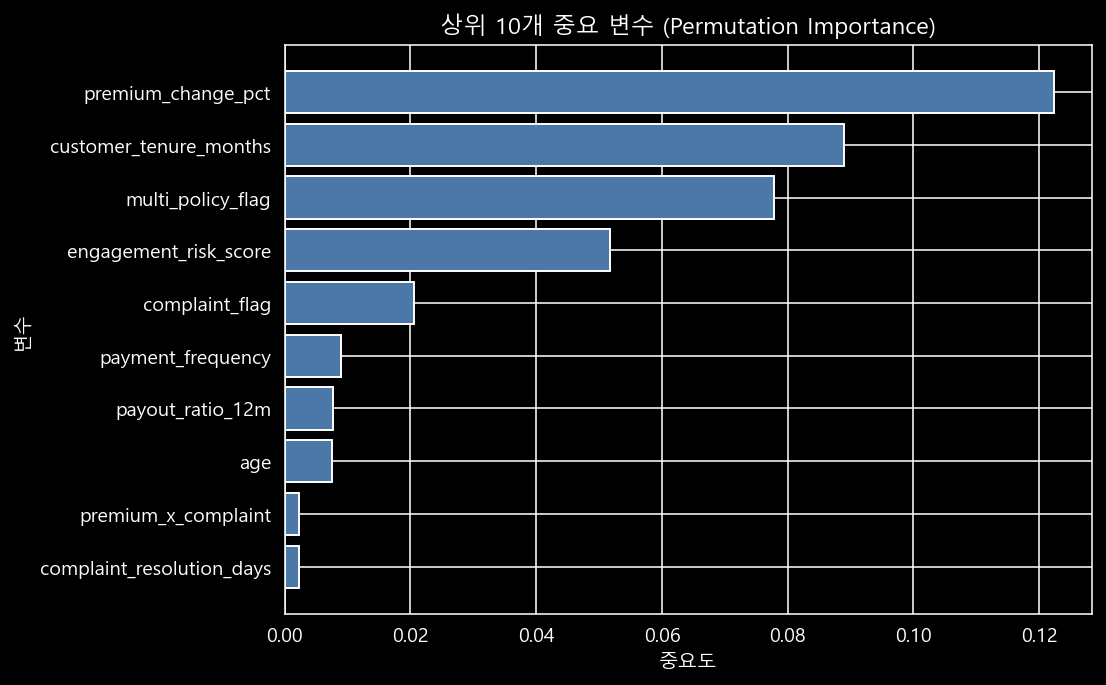

In [6]:
# Permutation importance로 현재 모델에서 실제로 강한 변수들을 표와 그래프로 확인한다.
if 'final_pipeline' not in globals() or 'X_test' not in globals() or 'y_test' not in globals():
    raise RuntimeError('이 셀은 먼저 모델 학습 셀을 실행한 뒤 사용하세요.')

from sklearn.inspection import permutation_importance

importance_result = permutation_importance(
    final_pipeline,
    X_test,
    y_test,
    n_repeats=5,
    random_state=42,
    scoring='average_precision',
    n_jobs=1,
)
importance_df = pd.DataFrame(
    {
        '변수': X_test.columns,
        'importance_mean': importance_result.importances_mean,
    }
).sort_values('importance_mean', ascending=False)

display(importance_df.head(15).reset_index(drop=True))

top_importance = importance_df.head(10).iloc[::-1]
fig, ax = plt.subplots(figsize=(8, 5), dpi=140)
ax.barh(top_importance['변수'], top_importance['importance_mean'], color='#4C78A8')
ax.set_title('상위 10개 중요 변수 (Permutation Importance)')
ax.set_xlabel('중요도')
ax.set_ylabel('변수')
plt.tight_layout()
plt.show()


## 5) 효과가 큰 파생변수와 상호작용 해석

아래 섹션은 파생변수 중 실제로 효과가 큰 것들을 시각적으로 확인하기 위한 보조 분석입니다.

특히 다음 변수들을 중점적으로 봅니다.
- `engagement_risk_score`: 납부 불안정과 서비스 불만 신호를 합친 변수
- `premium_increase_shock`: 보험료 인상폭과 최근 인상 횟수를 합친 변수
- `premium_x_complaint`: 보험료 급등과 민원이 동시에 있는 경우를 나타내는 상호작용 변수

이 단계에서는 단순 중요도 숫자뿐 아니라, 구간별 이탈률과 2차원 히트맵으로 조합 효과를 직접 확인합니다.

In [7]:
# 파생변수 중 상위 변수만 추려 설명용 표를 만든다.
if 'importance_df' not in globals():
    raise RuntimeError('먼저 중요 변수 계산 셀을 실행하세요.')

engineered_feature_names = [
    'premium_increase_shock',
    'premium_jump_flag',
    'payment_risk_score',
    'service_risk_score',
    'engagement_risk_score',
    'tenure_inverse',
    'single_policy_short_tenure',
    'premium_x_complaint',
    'premium_x_quote',
    'late_x_quote',
    'downgrade_x_quote',
    'monthly_payment_flag',
    'monthly_x_premium_jump',
    'auto_or_health',
]

engineered_importance_df = importance_df[importance_df['변수'].isin(engineered_feature_names)].copy()
engineered_importance_df = engineered_importance_df.sort_values('importance_mean', ascending=False)
engineered_importance_df['순위'] = range(1, len(engineered_importance_df) + 1)
display(engineered_importance_df[['순위', '변수', 'importance_mean']].head(10).reset_index(drop=True))


,순위,변수,importance_mean
0,1,engagement_risk_score,0.051757
1,2,premium_x_complaint,0.002264
2,3,premium_increase_shock,0.001383
3,4,monthly_x_premium_jump,0.000585
4,5,single_policy_short_tenure,0.000107
5,6,payment_risk_score,0.000000
6,7,monthly_payment_flag,0.000000
7,8,service_risk_score,0.000000
8,9,auto_or_health,-0.000002
9,10,downgrade_x_quote,-0.000005


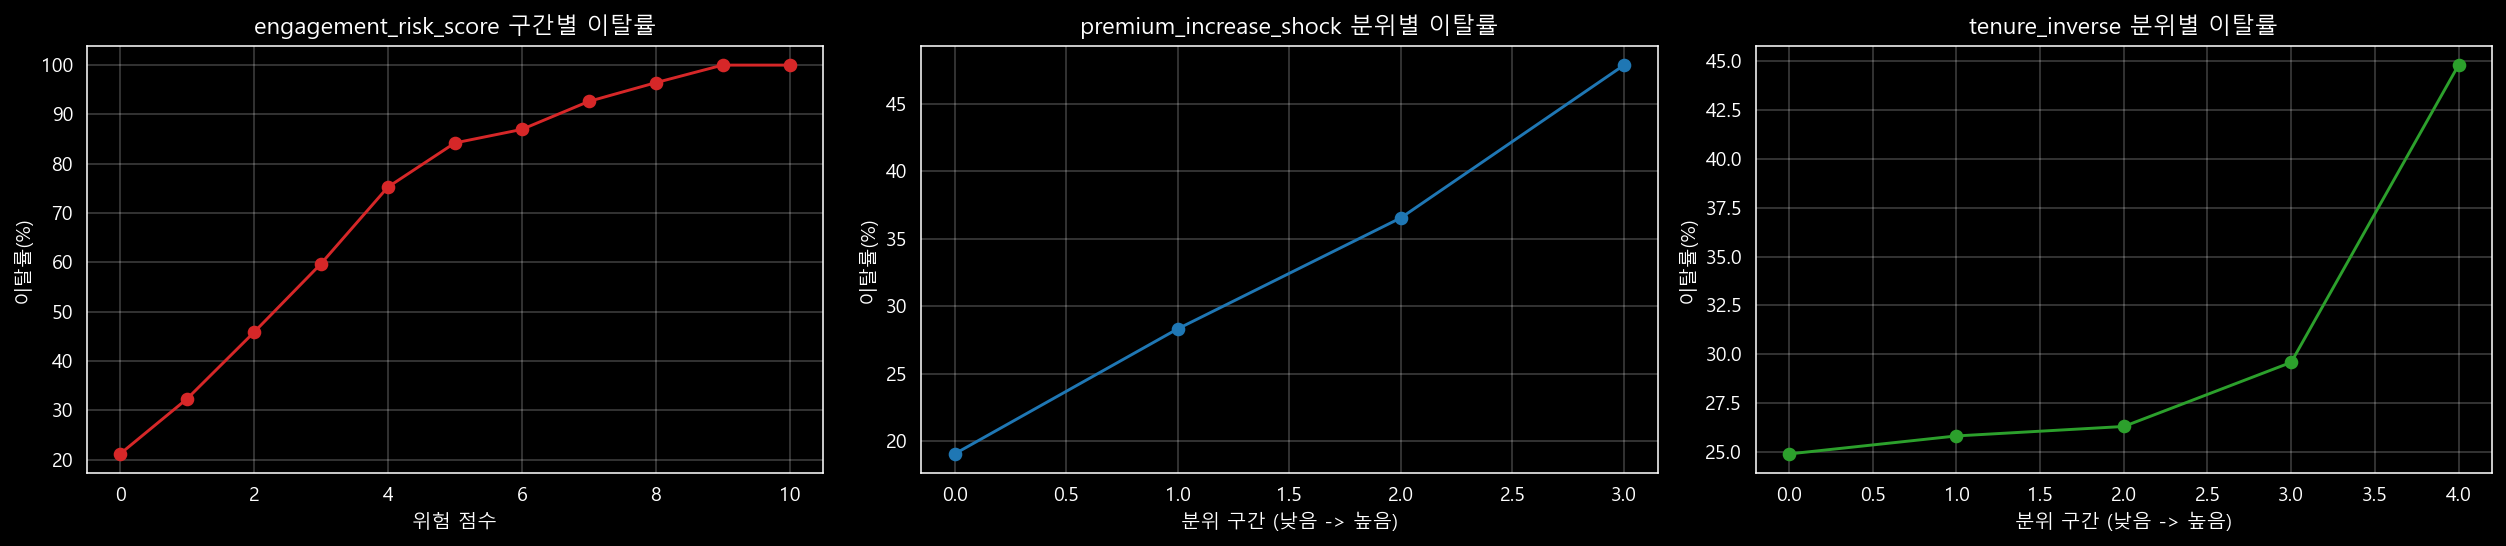

In [8]:
# 효과가 큰 파생변수 3개를 구간별로 나눠 이탈률을 본다.
if 'X' not in globals() or 'y' not in globals():
    raise RuntimeError('먼저 모델 학습 셀을 실행해 X와 y를 준비하세요.')

plot_feature_df = X.copy()
plot_feature_df['churn_flag'] = y

plot_feature_df['engagement_risk_bucket'] = plot_feature_df['engagement_risk_score'].astype(int)
plot_feature_df['premium_increase_shock_bucket'] = pd.qcut(
    plot_feature_df['premium_increase_shock'],
    q=5,
    duplicates='drop'
)
plot_feature_df['tenure_inverse_bucket'] = pd.qcut(
    plot_feature_df['tenure_inverse'],
    q=5,
    duplicates='drop'
)

engagement_summary = plot_feature_df.groupby('engagement_risk_bucket', as_index=False)['churn_flag'].mean()
premium_summary = plot_feature_df.groupby('premium_increase_shock_bucket', observed=False, as_index=False)['churn_flag'].mean()
tenure_summary = plot_feature_df.groupby('tenure_inverse_bucket', observed=False, as_index=False)['churn_flag'].mean()

fig, axes = plt.subplots(1, 3, figsize=(18, 4), dpi=140)

axes[0].plot(engagement_summary['engagement_risk_bucket'], engagement_summary['churn_flag'] * 100, marker='o', color='#D62728')
axes[0].set_title('engagement_risk_score 구간별 이탈률')
axes[0].set_xlabel('위험 점수')
axes[0].set_ylabel('이탈률(%)')
axes[0].grid(alpha=0.25)

axes[1].plot(range(len(premium_summary)), premium_summary['churn_flag'] * 100, marker='o', color='#1F77B4')
axes[1].set_title('premium_increase_shock 분위별 이탈률')
axes[1].set_xlabel('분위 구간 (낮음 -> 높음)')
axes[1].set_ylabel('이탈률(%)')
axes[1].grid(alpha=0.25)

axes[2].plot(range(len(tenure_summary)), tenure_summary['churn_flag'] * 100, marker='o', color='#2CA02C')
axes[2].set_title('tenure_inverse 분위별 이탈률')
axes[2].set_xlabel('분위 구간 (낮음 -> 높음)')
axes[2].set_ylabel('이탈률(%)')
axes[2].grid(alpha=0.25)

plt.tight_layout()
plt.show()


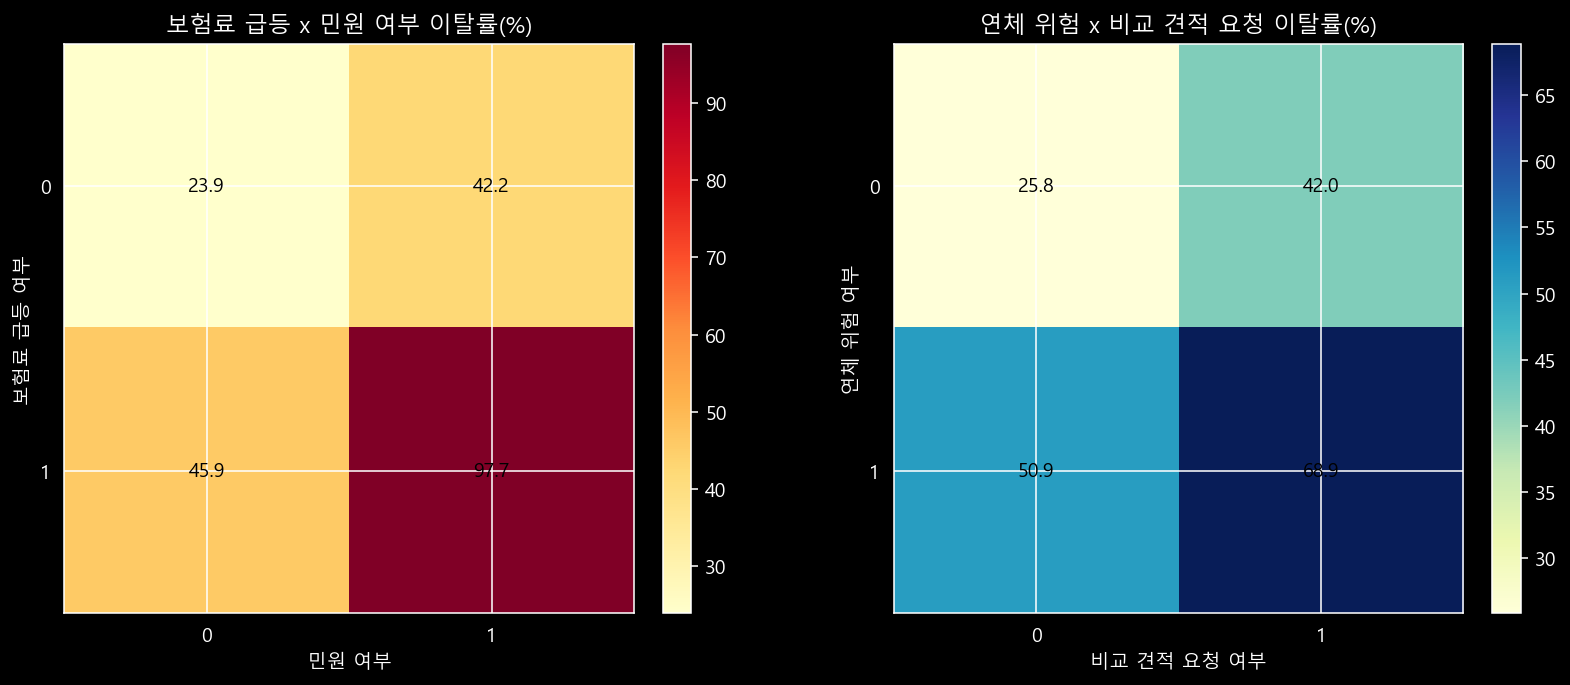

In [9]:
# 상호작용은 2차원 히트맵으로 본다.
if 'X' not in globals() or 'y' not in globals():
    raise RuntimeError('먼저 모델 학습 셀을 실행해 X와 y를 준비하세요.')

interaction_df = X.copy()
interaction_df['churn_flag'] = y
interaction_df['premium_jump_flag'] = interaction_df['premium_jump_flag'].astype(int)
interaction_df['complaint_flag'] = interaction_df['complaint_flag'].astype(int)
interaction_df['quote_requested_flag'] = interaction_df['quote_requested_flag'].astype(int)
interaction_df['late_payment_risk_flag'] = (interaction_df['late_payment_count_12m'] >= 2).astype(int)

heatmap_1 = interaction_df.pivot_table(
    index='premium_jump_flag',
    columns='complaint_flag',
    values='churn_flag',
    aggfunc='mean'
)
heatmap_2 = interaction_df.pivot_table(
    index='late_payment_risk_flag',
    columns='quote_requested_flag',
    values='churn_flag',
    aggfunc='mean'
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=140)

im1 = axes[0].imshow(heatmap_1.values * 100, cmap='YlOrRd')
axes[0].set_title('보험료 급등 x 민원 여부 이탈률(%)')
axes[0].set_xlabel('민원 여부')
axes[0].set_ylabel('보험료 급등 여부')
axes[0].set_xticks(range(len(heatmap_1.columns)))
axes[0].set_xticklabels(heatmap_1.columns.tolist())
axes[0].set_yticks(range(len(heatmap_1.index)))
axes[0].set_yticklabels(heatmap_1.index.tolist())
for i in range(heatmap_1.shape[0]):
    for j in range(heatmap_1.shape[1]):
        axes[0].text(j, i, f"{heatmap_1.values[i, j] * 100:.1f}", ha='center', va='center', color='black')

im2 = axes[1].imshow(heatmap_2.values * 100, cmap='YlGnBu')
axes[1].set_title('연체 위험 x 비교 견적 요청 이탈률(%)')
axes[1].set_xlabel('비교 견적 요청 여부')
axes[1].set_ylabel('연체 위험 여부')
axes[1].set_xticks(range(len(heatmap_2.columns)))
axes[1].set_xticklabels(heatmap_2.columns.tolist())
axes[1].set_yticks(range(len(heatmap_2.index)))
axes[1].set_yticklabels(heatmap_2.index.tolist())
for i in range(heatmap_2.shape[0]):
    for j in range(heatmap_2.shape[1]):
        axes[1].text(j, i, f"{heatmap_2.values[i, j] * 100:.1f}", ha='center', va='center', color='black')

fig.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04)
fig.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()
